# Automatic Deep Research Flow and Observability  


## Introduction  

This project implements a lightweight, **multi-agent content creation workflow using CrewAI CLI**. It leverages a structured pipeline where a writer generates comprehensive reports on diverse topics and a reviewer refines it, ensuring clarity, consistency, and quality. The workflow is designed to be simple, interactive, and adaptable to different topics and audience levels.  


## Background  

Creating high-quality comprehensive reports on diverse topics  typically requires multiple steps, including drafting, reviewing, and refining. Manually coordinating these steps can be time-consuming and inconsistent, especially when targeting **different audience levels (beginner, intermediate, advanced)**. There is a need for a streamlined, automated approach that maintains quality while reducing effort and complexity.  

## Solution

The solution uses a **sequential CrewAI workflow** with two specialized agents:**a content writer and a content reviewer**. The writer generates a structured draft based on user input, while the reviewer improves accuracy, readability, and coherence. By passing context between tasks, the system ensures continuity and produces polished, publication-ready content in a fully automated manner.  

## Why using CrewAI CLI

Using the **CrewAI CLI** simplifies setup and execution by providing a ready-to-use project structure, configuration files, and interactive input prompts. It allows users to quickly initialize, customize, and run crews without managing complex orchestration logic manually. This makes the workflow easy to deploy, reproducible, and accessible, even for users with minimal setup experience.

## Workflow architecture  

Here the crew is embed  into a Flow, that actually decides whether the deep research crew is needed or not.

### Content Creation Crew — Sequential Workflow  

The below diagram show the sequential flow of the Content Creation Crew:

```bash  
User Input (section_title, section_description, audience_level, previous_sections)
   ↓

[🧑‍💻 Content Writer Agent]  
Role: Educational Content Writer  
Goal: Create engaging, informative content that clearly explains the assigned topic  
Tools: None (writing + reasoning)

   ↓
   [Execute Task: write_section_task]
   ← Writes a structured section (500–800 words)  
   ← Explains key concepts with examples  
   ← Adds practical applications or exercises  
   ← Ensures consistency with previous sections  
   ← Formats output in Markdown  
   ↓

[📝 Draft Section Output]

   ↓

[🧐 Content Reviewer Agent]  
Role: Educational Content Reviewer and Editor  
Goal: Improve clarity, accuracy, and consistency of the content  
Tools: None (editing + validation)

   ↓
   [Execute Task: review_section_task]
   ← Fixes grammar and spelling issues  
   ← Improves readability and flow  
   ← Ensures accuracy and completeness  
   ← Verifies consistency with previous sections  
   ← Enhances structure and formatting  
   ↓

📘 Final Section (Polished, publication-ready Markdown)
```  

## Set Up the Notebook  

Begin by setting up the notebook by importing all necessary modules, and configuring the environment variables so you can connect to OpenAI.

In [1]:
pip install crewai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 3.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opentelemetry-exporter-otlp-proto-grpc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of typer to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 967.5/967.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

## Inspecting the flow structure   

Here, it will be given an insight  how to build a `flow`, which includes the deep research crew created previously.

If you were to create the flow from scratch,  running the following command on a terminal:

```bash
crewai create flow deep_research_flow
```

However,  you are already provided with the structure of the flow, so that we can guide you through the building process. As you can see, the structure consists of a `src` folder that has inside the folder named `crews`. In it you will find all the files needed to create the crew.  
The **CLI command crewai** create **flow deep_research_flow** initializes a new CrewAI flow project named deep_research_flow. It automatically generates a structured project scaffold, including directories for crews, configuration files (such as agents.yaml and tasks.yaml), and starter Python modules. This template provides a ready-to-use foundation for building multi-agent workflows, allowing you to quickly define agents, tasks, and execution logic without setting up the project from scratch.

The below figure gives an overview the the repository structure created after running `crewai create flow deep_research_flow`.

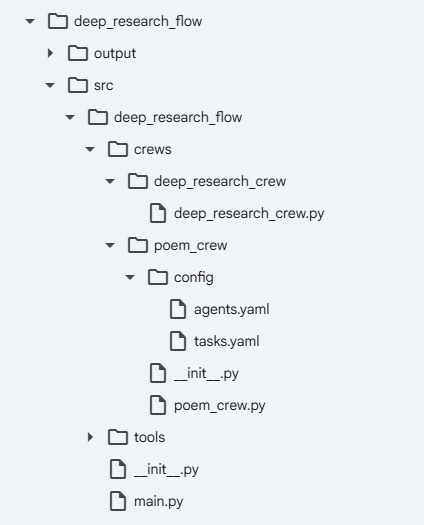

In [ ]:
from IPython.display import Image, display
display(Image('repo_structure.jpeg'))

## Configure the Flow  

Template files are provided to help you quickly set up your workflow. After running the command crewai create flow deep_research_flow, the CLI generates the above project structure with placeholder configuration and code files. You can simply copy the contents of the provided templates into the corresponding files within this generated structure, allowing you to customize agents, tasks, and logic without building everything from scratch.

When launching the crew using the CLI (crewai run), the system interactively prompts the user to provide key inputs, such as the query (topic or section to generate) and the target audience level (beginner, intermediate, or advanced). These inputs are then dynamically injected into the task descriptions, allowing the agents to tailor the content accordingly. This ensures that the generated output is both context-aware and aligned with the desired level of complexity, making the workflow flexible and user-driven.

In [ ]:
# run this cell to avoid warnings
import warnings
warnings.filterwarnings("ignore")

##  Run the Flow  

Now you are ready to kickoff the Flow! Since this flow interacts with the user by asking for the question, and possibly some clarifications, open a terminal and run

```bash
cd deep_research_flow
crewai run
```
or
```bash
cd deep_research_flow && crewai run
```

When launching the crew using the CLI (crewai run), the system interactively prompts the user to provide key inputs, such as the **query (topic or section to generate)** and the **target audience level (beginner, intermediate, or advanced)**. These inputs are then dynamically injected into the task descriptions, allowing the agents to tailor the content accordingly. This ensures that the generated output is both context-aware and aligned with the desired level of complexity, making the workflow flexible and user-driven.


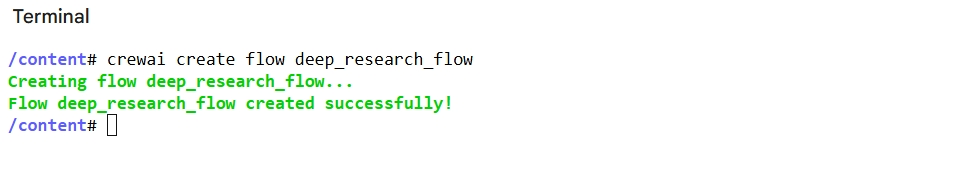

In [3]:
from IPython.display import Image, display
display(Image('Screenshots_cli_terminal/Screenshot_flow_terminal1.jpeg'))

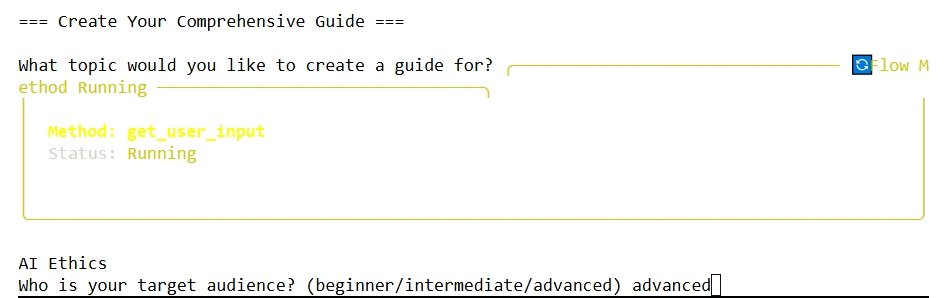

In [4]:
from IPython.display import Image, display
display(Image('Screenshots_cli_terminal/Screenshot_flow_terminal2.jpeg'))

Once it finishes, you should see something like this

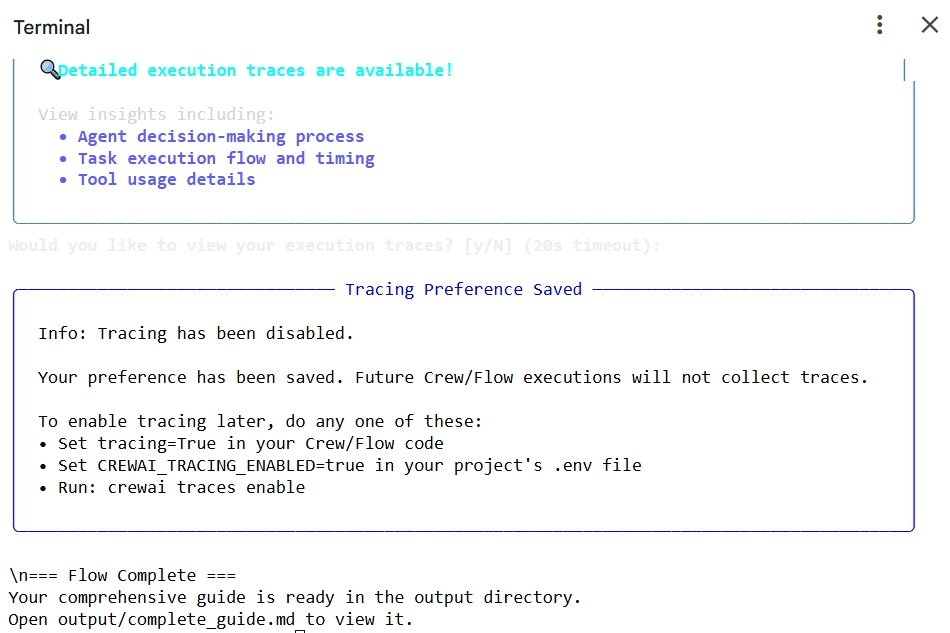

In [5]:
from IPython.display import Image, display
display(Image('Screenshots_cli_terminal/Screenshot_flow_terminal3.jpeg'))

## Conclusion  

This workflow demonstrates how a simple, structured multi-agent system can effectively automate content creation while maintaining quality and consistency. By combining a writer and reviewer in a sequential process, the solution balances efficiency with reliability, producing clear and well-structured outputs. Leveraging the CrewAI CLI further enhances usability, making the system easy to initialize, run, and adapt to different use cases.

## Further Improvements

Experiment with different queries so that you see the research Crew triggered.     
While effective, the workflow can be further enhanced by introducing additional agents (e.g., fact-checker or planner) to improve depth and accuracy. Incorporating parallel execution could speed up processing for larger content generation tasks. Adding tool integrations (e.g., search or retrieval) would enrich the content with external knowledge. Finally, enabling memory and context persistence across multiple sections could support more complex, long-form content generation such as full guides or reports.

